# TianoCore Survey EDA
## Section 3: Bug Management (Q2–Q23)

---
Survey period: March 8–25, 2026 | Participants: 13

### Step 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


### Step 2 — Install dependencies

In [2]:
!pip install matplotlib pandas -q

### Step 3 — Setup: load data and helpers

In [3]:
import os, re, pandas as pd, matplotlib.pyplot as plt
from collections import Counter, OrderedDict

# ── CONFIG ────────────────────────────────────────────────────────────────────
CSV_PATH = "/content/drive/MyDrive/TS-Survey/tianocore-survey_cleaned.csv"
OUT_DIR  = "/content/drive/MyDrive/TS-Survey/figures"
os.makedirs(OUT_DIR, exist_ok=True)

C_MAIN   = "#ffb07c"
C_SECOND = "#B4B2A9"
PIE_PALETTE = ["#ffb07c","#FFF4B3","#FFD7EE","#FAC775","#F0997B","#97C459","#B4B2A9"]

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.grid": True, "axes.grid.axis": "x",
    "grid.color": "#ebebeb", "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "xtick.labelsize": 9, "ytick.labelsize": 10,
})

df = pd.read_csv(CSV_PATH, header=0, skiprows=[1, 2])
N  = len(df)

# Exact choices from QSF — used to split multi-select responses correctly
QSF_CHOICES = {'Q1': ['Original Equipment Manufacturer (OEM)', 'Independent Firmware/BIOS Vendor', 'Another role in industry (e.g., firmware security expert/practitioner)', 'Another role in academia (e.g., researcher)', 'I do not know about TianoCore.', 'I know about TianoCore, but I do not belong to this ecosystem.', 'Others (please specify)'], 'Q5': ['Jira', 'GitHub Issues', 'GitLab Issues', 'Bugzilla', 'Azure DevOps', 'Other'], 'Q6': ['It is access-restricted (e.g., requires approval, access allowed to only employees, etc.).', 'Open Access: It is open with read access for everyone, and everyone can report a new issue.', 'Open Read Access but Restricted Write Access (a): It is open to everyone for read access, but only specific people can report new issues.', 'Open Read Access but Restricted Write Access (b): It is open to everyone for read access and write access to report new issues, but only specific people can update the reported issues (e.g., adding comments or changing fields).'], 'Q8': ['Bug Description (What is the issue? Expected behavior vs. observed behavior)', 'Proof of Concept (PoC) or Steps to Reproduce', 'Target Environment (System/hardware configuration where the bug is observed)', 'Impact (How exactly does the bug affect the functionality of the firmware)', 'Potential Patch or Fix suggestion', 'Suggested CVSS and CWE scoring', 'Files and packages impacted', 'Affected versions', 'Bug introducing commit', 'Others (please explain)'], 'Q9': ['Severity (e.g., potentially affecting many users/organizations)', 'Availability of steps to reproduce (i.e., a concrete case is available for the bug)', 'Availability of proposed patch', 'Availability of unit test / PoC / other test cases', 'Type of fix (e.g., easy fix vs. architecture design change)', 'Active maintainer for the given subsystem', 'Others (please explain)'], 'Q13': ['Always', 'Only for security bugs', 'Only for bugs affecting core functionality', "At the developers' discretion", 'Others (please explain)'], 'Q14': ['Upstream issue tracker associated with the repository (e.g., trackers from question Q3)', 'Security mailing lists', "Through a vendor's website", 'Informal communication (e.g., email)', 'Others (please explain)', 'Not applicable (i.e., we do not explicitly report to upstream)'], 'Q29': ['Bug fixes', 'Security fixes', 'Refactorings or cleanups', 'Feature additions'], 'Q38': ['Compiler-based warnings', 'Commercial SAST tools', 'Open-source static analyzers', 'Semantic/code-query tools', 'None'], 'Q54': ['Toolchain limitations', 'Performance concerns', 'Integration with existing C code', 'Lack of internal expertise', 'Other'], 'Q62': ['Automated build verification', 'Automated regression testing', 'Static analysis / SAST', 'Dynamic analysis / fuzzing', 'Security policy or compliance checks', 'Automated issue or alert generation', 'Others (please specify)'], 'Q63': ['Atlassian Bamboo', 'Azure Pipelines', 'Buildkite', 'CircleCI', 'Concourse', 'GitHub Actions (Workflows)', 'GitLab CI/CD', 'GoCD', 'Jenkins', 'Screwdriver', 'Spinnaker', 'TeamCity', 'Tekton Pipelines', 'Travis CI', 'Others (please specify)'], 'Q65': ['Manual review of upstream code or releases', 'Tracking dependencies using internal documentation or spreadsheets', 'Monitoring CVEs or vulnerability databases', 'Automated dependency or supply-chain scanning tools', 'Vendor-provided assurances or certifications', 'We do not perform explicit supply-chain verification'], 'Q66': ['Limited tooling support', 'Lack of standardized metadata', 'Scale or complexity of dependencies', 'Limited staffing or expertise', 'Performance or integration concerns', 'No major challenges', 'Other'], 'Q71': ['Open-source firmware development (e.g., TianoCore/EDK II)', 'Proprietary firmware development based on TianoCore/UEFI', 'Firmware security analysis or auditing', 'Research or experimental firmware development', 'Tooling or infrastructure supporting firmware development (e.g., CI, testing, or analysis)', 'Legal, policy, and/or compliance', 'Others (please specify)'], 'Q72': ['Firmware developer', 'Firmware PSIRT/SSDLC, security engineer, analyzer, tester, or reviewer', 'Firmware maintainer', 'Tool developer for firmware testing, analysis, or DevOps/DevSecOps', 'Project manager or technical lead', 'Researcher', 'Others (please specify)'], 'Q80': ['Lack of expertise or training', 'Cost of tools or infrastructure', 'Complexity of firmware security tooling', 'Limited documentation or educational resources', 'Competing operational priorities', 'No significant barriers', "Don't know", 'Other'], 'Q81': ['Better documentation and tutorials', 'Open-source security analysis tools', 'Training programs or workshops', 'Academic–industry collaboration', 'Automated security validation services', 'Other'], 'Q82': ['Increased engineering or remediation effort', 'Release delays or operational downtime', 'Compliance or certification overhead', 'Reputational or customer trust impact', 'Minimal or negligible impact', 'Not applicable', 'Other']}

def simple_counts(col):
    return Counter(df[col].dropna().tolist())

def multi_counts(col):
    """Split using exact QSF choices so no label is ever fragmented."""
    known = QSF_CHOICES.get(col, [])
    c = Counter()
    for val in df[col].dropna():
        val = str(val).strip()
        if not val or val == "nan":
            continue
        if known:
            # Greedy match against known choices (longest first)
            remaining = val
            found = []
            known_sorted = sorted(known, key=len, reverse=True)
            while remaining:
                matched = False
                for option in known_sorted:
                    if remaining.startswith(option):
                        found.append(option)
                        remaining = remaining[len(option):].lstrip(", ")
                        matched = True
                        break
                if not matched:
                    # fallback: take up to next comma+capital
                    m = re.search(r',(?=[A-Z])', remaining)
                    if m:
                        found.append(remaining[:m.start()].strip())
                        remaining = remaining[m.end():].strip()
                    else:
                        found.append(remaining.strip())
                        break
            for item in found:
                if item: c[item] += 1
        else:
            for item in re.split(r',(?=[A-Z])', val):
                item = item.strip()
                if item: c[item] += 1
    return c

# Only gray for exact catch-all labels
CATCHALL = ["others (please specify)", "other (please specify)", "others (please explain)",
            "other (please explain)", "other", "prefer not to say", "prefer to self-describe",
            "i do not know about tianocore.", "i know about tianocore, but i do not belong to this ecosystem.",
            "don't know", "no incentive needed", "not applicable", "none"]

def pick(label):
    return C_SECOND if label.lower().strip() in CATCHALL else C_MAIN

def save(fig, name):
    path = os.path.join(OUT_DIR, name)
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor="white")
    plt.show(); plt.close(fig)
    print(f"Saved: {name}")

def hbar(cnt, fname, max_x=None, note=""):
    if not cnt: print(f"Skipped {fname} — no data"); return
    items  = list(cnt.items())
    labels = [i[0] for i in items]; vals = [i[1] for i in items]
    h = max(3.0, 0.7*len(items)+1.2)
    fig, ax = plt.subplots(figsize=(12, h))
    bars = ax.barh(labels[::-1], vals[::-1],
                   color=[pick(l) for l in labels[::-1]], height=0.5, zorder=3)
    ax.set_xlabel("Number of respondents", fontsize=10)
    ax.set_xlim(0, (max_x or max(vals))+1.5)
    ax.yaxis.set_tick_params(labelsize=10)
    for bar, v in zip(bars, vals[::-1]):
        if v > 0:
            ax.text(v+0.06, bar.get_y()+bar.get_height()/2,
                    str(v), va="center", fontsize=11, fontweight="bold")
    if note:
        fig.text(0.02, -0.04, f"Note: {note}", fontsize=8, color="#666", ha="left", style="italic")
    fig.subplots_adjust(left=0.45); save(fig, fname)

def pie(cnt, fname):
    if not cnt: print(f"Skipped {fname} — no data"); return
    items  = list(cnt.items())
    labels = [i[0] for i in items]; vals = [i[1] for i in items]
    colours = [PIE_PALETTE[i % len(PIE_PALETTE)] for i in range(len(items))]
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    wedges, _, autotexts = ax.pie(vals, colors=colours, autopct="%1.0f%%",
                                   startangle=90, wedgeprops=dict(width=0.55), pctdistance=0.75)
    for at in autotexts: at.set_fontsize(10); at.set_fontweight("bold"); at.set_color("black")
    ax.legend(wedges, [f"{l} ({v})" for l, v in zip(labels, vals)],
              loc="lower center", bbox_to_anchor=(0.5,-0.22), fontsize=9, frameon=False, ncol=2)
    fig.tight_layout(); save(fig, fname)

print(f"Loaded {N} participants. Helpers ready.")


Loaded 13 participants. Helpers ready.


## Q2 & Q3 — Knowledge and Issue Tracking

Q2 — Bug Mgmt Knowledge (n=12/13):
  Yes: 10
  No: 2


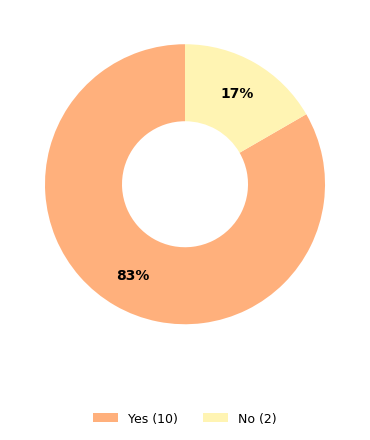

Saved: fig_14_bug_mgmt_knowledge.png

Q3 — Uses Issue Tracking (n=10/13):
  Yes: 6
  No: 4


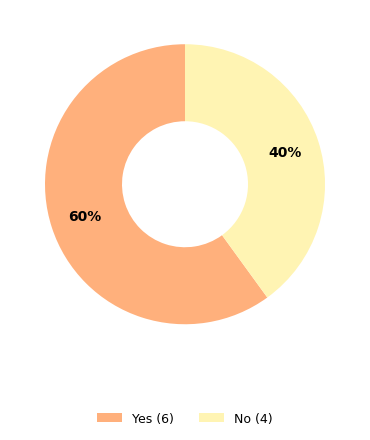

Saved: fig_15_uses_issue_tracking.png


In [4]:
q2 = simple_counts("Q2")
print(f"Q2 — Bug Mgmt Knowledge (n={sum(q2.values())}/{N}):")
for k,v in q2.items(): print(f"  {k}: {v}")
pie(q2, "fig_14_bug_mgmt_knowledge.png")

q3 = simple_counts("Q3")
print(f"\nQ3 — Uses Issue Tracking (n={sum(q3.values())}/{N}):")
for k,v in q3.items(): print(f"  {k}: {v}")
pie(q3, "fig_15_uses_issue_tracking.png")


## Q5 — Issue Tracker Tools

Q5 — Issue Tracker Tools (n=7/13):
  GitHub Issues: 5
  Bugzilla: 3
  Jira: 2
  Other: 1
  Azure DevOps: 1


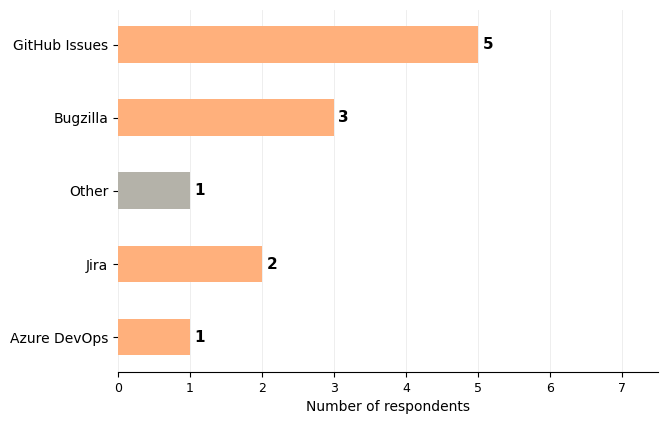

Saved: fig_16_tracker_tools.png


In [5]:
q5 = multi_counts("Q5")
n_q5 = df["Q5"].notna().sum()
print(f"Q5 — Issue Tracker Tools (n={n_q5}/{N}):")
for k,v in q5.most_common(): print(f"  {k}: {v}")
hbar(q5, "fig_16_tracker_tools.png", max_x=6,
    # note=f"Multi-select: {n_q5} respondents."
     )


## Q6 — Tracker Access Level

Q6 — Tracker Access (n=6/13):
  It is access-restricted (e.g., requires approval, access allowed to only employees, etc.).: 4
  Open Access: It is open with read access for everyone, and everyone can report a new issue.: 2


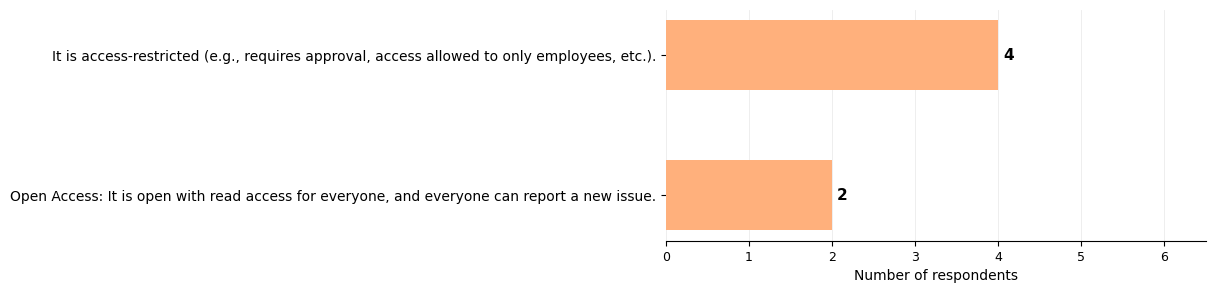

Saved: fig_17_tracker_access.png


In [6]:
q6 = multi_counts("Q6")
n_q6 = df["Q6"].notna().sum()
print(f"Q6 — Tracker Access (n={n_q6}/{N}):")
for k,v in q6.most_common(): print(f"  {k}: {v}")
hbar(q6, "fig_17_tracker_access.png", max_x=5)


## Q8 — Expected Bug Report Info

Q8 — Bug Report Info (n=6/13):
  Bug Description (What is the issue? Expected behavior vs. observed behavior): 6
  Proof of Concept (PoC) or Steps to Reproduce: 5
  Target Environment (System/hardware configuration where the bug is observed): 5
  Impact (How exactly does the bug affect the functionality of the firmware): 5
  Potential Patch or Fix suggestion: 4
  Files and packages impacted: 4
  Affected versions: 4
  Suggested CVSS and CWE scoring: 3
  Bug introducing commit: 2


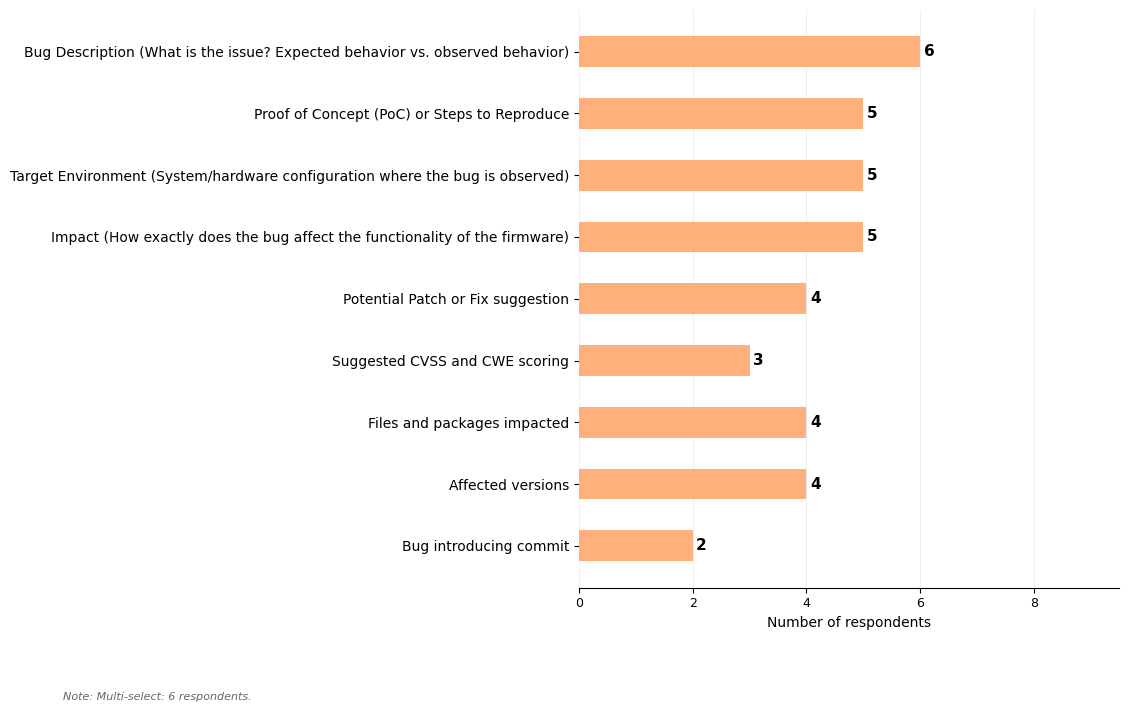

Saved: fig_18_bug_report_info.png


In [7]:
q8 = multi_counts("Q8")
n_q8 = df["Q8"].notna().sum()
print(f"Q8 — Bug Report Info (n={n_q8}/{N}):")
for k,v in q8.most_common(): print(f"  {k}: {v}")
hbar(q8, "fig_18_bug_report_info.png", max_x=8,
     note=f"Multi-select: {n_q8} respondents.")


## Q9 — Bug Prioritisation Factors

Q9 — Prioritisation Factors (n=6/13):
  Severity (e.g., potentially affecting many users/organizations): 5
  Availability of steps to reproduce (i.e., a concrete case is available for the bug): 3
  Type of fix (e.g., easy fix vs. architecture design change): 3
  Availability of proposed patch: 2
  Availability of unit test / PoC / other test cases: 2
  Active maintainer for the given subsystem: 1


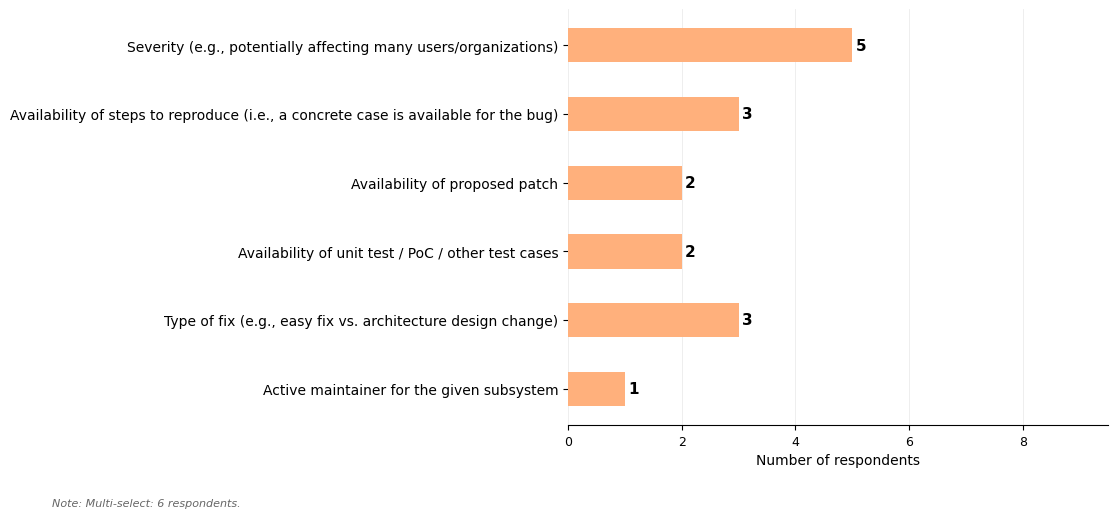

Saved: fig_19_priority_factors.png


In [8]:
q9 = multi_counts("Q9")
n_q9 = df["Q9"].notna().sum()
print(f"Q9 — Prioritisation Factors (n={n_q9}/{N}):")
for k,v in q9.most_common(): print(f"  {k}: {v}")
hbar(q9, "fig_19_priority_factors.png", max_x=8,
     note=f"Multi-select: {n_q9} respondents.")


## Q10 — Bug Priority Rankings

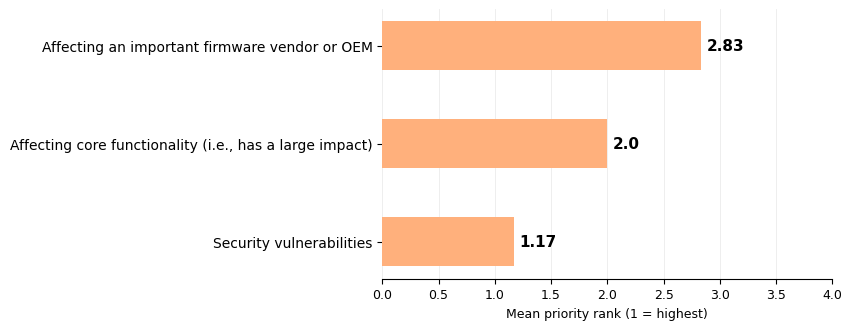

Saved: fig_20_bug_priority_ranking.png
Q10 — Bug Priority Rankings (mean rank, 1=highest):
  Security vulnerabilities: 1.17
  Affecting core functionality (i.e., has a large impact): 2.0
  Affecting an important firmware vendor or OEM: 2.83


In [9]:
bug_types = {"Q10_1": "Affecting core functionality (i.e., has a large impact)",
             "Q10_2": "Security vulnerabilities",
             "Q10_3": "Affecting an important firmware vendor or OEM"}
means = {label: round(df[col].dropna().mean(), 2) for col, label in bug_types.items()}
sorted_means = dict(sorted(means.items(), key=lambda x: x[1]))
fig, ax = plt.subplots(figsize=(10, 3.5))
labels = list(sorted_means.keys()); vals = list(sorted_means.values())
bars = ax.barh(labels, vals, color=C_MAIN, height=0.5, zorder=3)
ax.set_xlabel("Mean priority rank (1 = highest)", fontsize=9)
ax.set_xlim(0, 4)
for bar, v in zip(bars, vals):
    ax.text(v+0.05, bar.get_y()+bar.get_height()/2, str(v), va="center", fontsize=11, fontweight="bold")
fig.subplots_adjust(left=0.45); save(fig, "fig_20_bug_priority_ranking.png")
print("Q10 — Bug Priority Rankings (mean rank, 1=highest):")
for k,v in sorted_means.items(): print(f"  {k}: {v}")


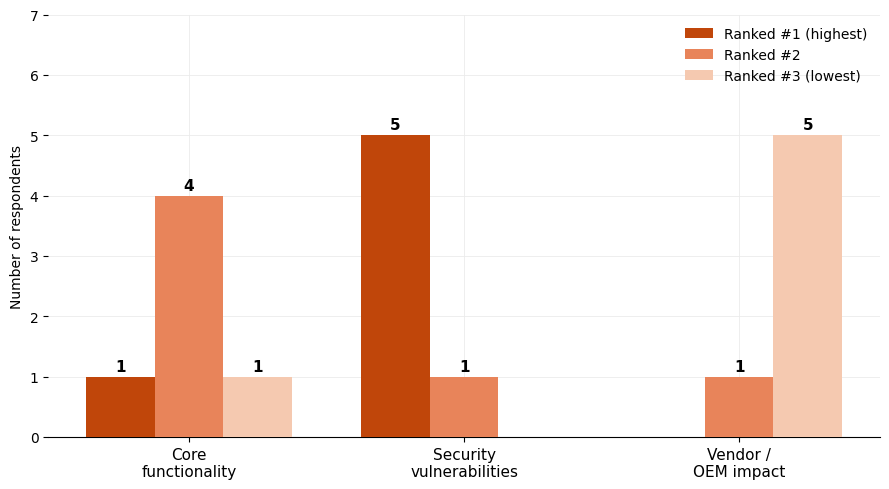

Saved: fig_20_bug_priority_ranking.png
Saved: fig_20_bug_priority_ranking.png


In [17]:
# Q10 — Bug Priority Rankings (grouped bar chart)
import numpy as np

categories = ['Core\nfunctionality', 'Security\nvulnerabilities', 'Vendor /\nOEM impact']
rank1 = [1, 5, 0]  # ranked #1 (highest)
rank2 = [4, 1, 1]  # ranked #2
rank3 = [1, 0, 5]  # ranked #3 (lowest)

x = np.arange(len(categories))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))

b1 = ax.bar(x - width, rank1, width, label='Ranked #1 (highest)', color='#C0460A', zorder=3)
b2 = ax.bar(x,          rank2, width, label='Ranked #2',           color='#E8845A', zorder=3)
b3 = ax.bar(x + width,  rank3, width, label='Ranked #3 (lowest)',  color='#F5C9B0', zorder=3)

# Add value labels on bars
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.05,
                    str(int(h)), ha='center', va='bottom',
                    fontsize=11, fontweight='bold')

ax.set_ylabel('Number of respondents')
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 7)
ax.legend(loc='upper right', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='#ebebeb', linewidth=0.6)
ax.set_axisbelow(True)

fig.tight_layout()
save(fig, "fig_20_bug_priority_ranking.png")
print("Saved: fig_20_bug_priority_ranking.png")

## Q11 & Q12 — Severity and Priority Definitions

Q11 — Severity Definition (n=6/13):
  The security impact of the issue (e.g., vulnerability severity, data exposure, exploitability): 3
  The technical criticality of the defect (e.g., affects core vs peripheral components): 1
  The impact level of the issue on the product: 1
  The degree of functional degradation (e.g., crash, data loss, minor defect): 1


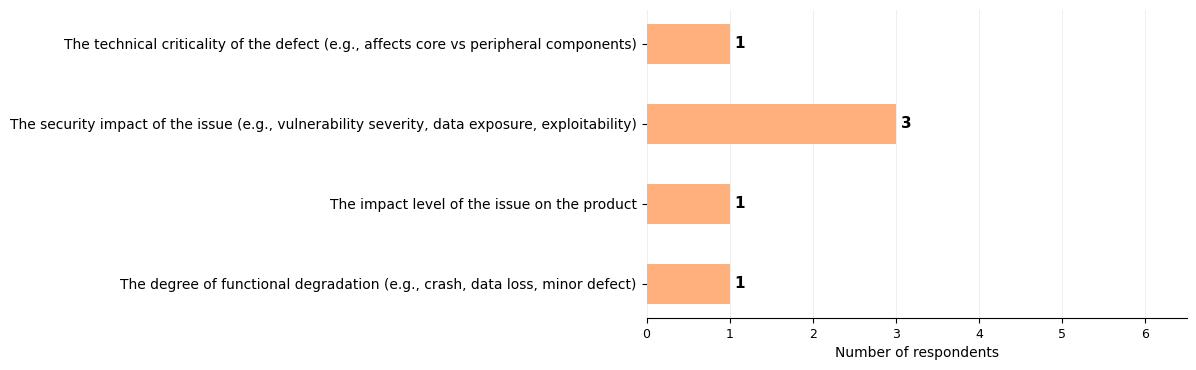

Saved: fig_21_severity_def.png

Q12 — Priority Definition (n=6/13):
  The importance or urgency of fixing the issue: 3
  The risk level (operational, financial, or reputational) associated with the issue: 3


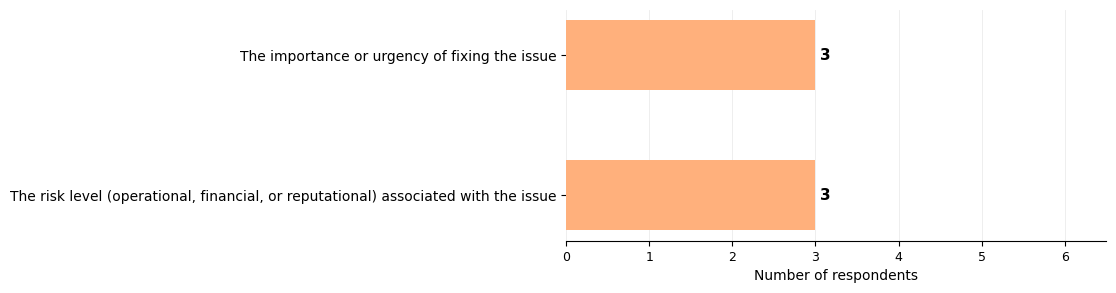

Saved: fig_22_priority_def.png


In [10]:
q11 = simple_counts("Q11")
print(f"Q11 — Severity Definition (n={sum(q11.values())}/{N}):")
for k,v in q11.most_common(): print(f"  {k}: {v}")
hbar(q11, "fig_21_severity_def.png", max_x=5)

q12 = simple_counts("Q12")
print(f"\nQ12 — Priority Definition (n={sum(q12.values())}/{N}):")
for k,v in q12.most_common(): print(f"  {k}: {v}")
hbar(q12, "fig_22_priority_def.png", max_x=5)


## Q13 & Q14 — Upstreaming Conditions and Methods

Q13 — Upstreaming Conditions (n=6/13):
  Only for security bugs: 4
  Only for bugs affecting core functionality: 2
  Always: 2
  At the developers' discretion: 1


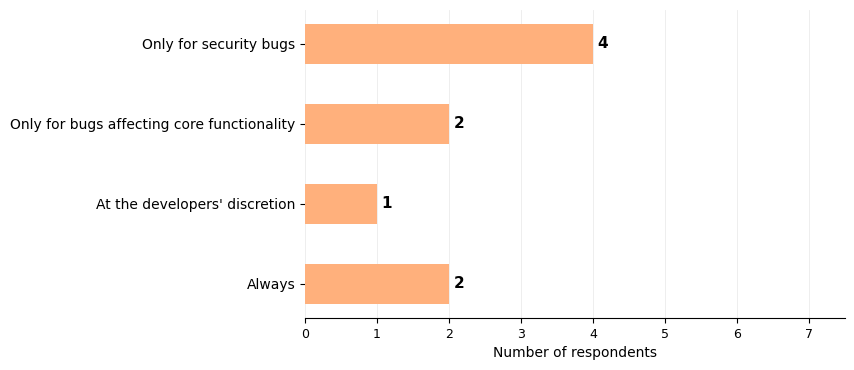

Saved: fig_23_upstream_conditions.png

Q14 — How to Upstream (n=8/13):
  Upstream issue tracker associated with the repository (e.g., trackers from question Q3): 6
  Security mailing lists: 3
  Informal communication (e.g., email): 2
  Through a vendor's website: 1
  Others (please explain): 1
  Not applicable (i.e., we do not explicitly report to upstream): 1


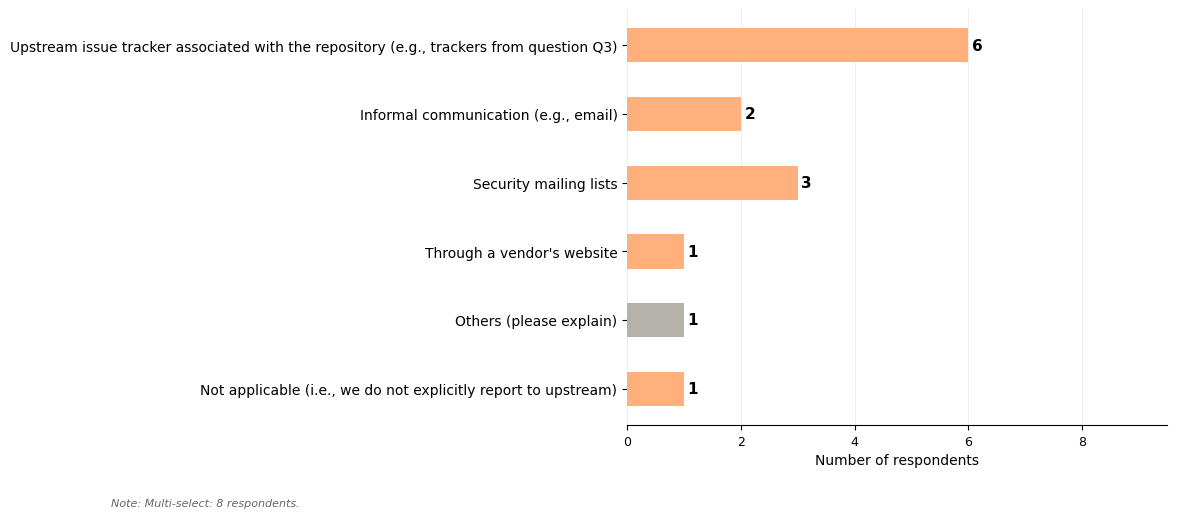

Saved: fig_24_how_upstream.png


In [11]:
q13 = multi_counts("Q13")
n_q13 = df["Q13"].notna().sum()
print(f"Q13 — Upstreaming Conditions (n={n_q13}/{N}):")
for k,v in q13.most_common(): print(f"  {k}: {v}")
hbar(q13, "fig_23_upstream_conditions.png", max_x=6,
    # note=f"Multi-select: {n_q13} respondents."
     )

q14 = multi_counts("Q14")
n_q14 = df["Q14"].notna().sum()
print(f"\nQ14 — How to Upstream (n={n_q14}/{N}):")
for k,v in q14.most_common(): print(f"  {k}: {v}")
hbar(q14, "fig_24_how_upstream.png", max_x=8,
     note=f"Multi-select: {n_q14} respondents.")


## Q15 — Provide Fix When Upstreaming

Q15 — Provide Fix Upstream (n=7/13):
  Yes: 6
  No: 1


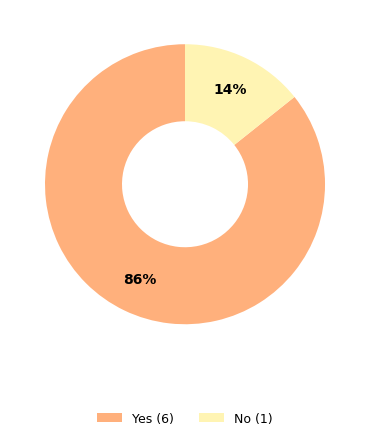

Saved: fig_25_provide_fix_upstream.png


In [12]:
q15 = simple_counts("Q15")
print(f"Q15 — Provide Fix Upstream (n={sum(q15.values())}/{N}):")
for k,v in q15.items(): print(f"  {k}: {v}")
pie(q15, "fig_25_provide_fix_upstream.png")


## Q19 & Q20 — Triage Method and Automated PoC Tools

Q19 — Bug Triage Method (n=6/13):
  A small group of developers is responsible for bug triage (triagers). This is done manually.: 4
  A small group of developers is responsible for bug triage (triagers). This is in part technology-assisted (e.g., using AI).: 1
  All developers are involved in bug triage. This is partly technology-assisted (e.g., using AI).: 1


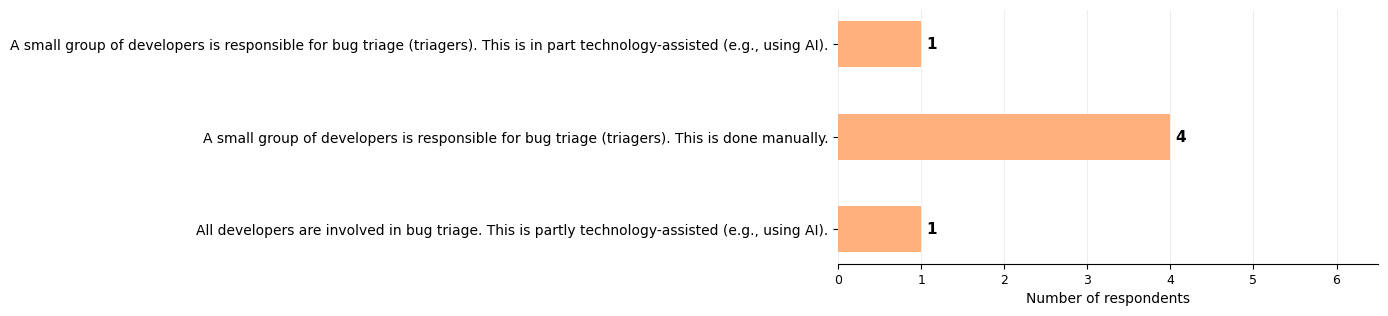

Saved: fig_26_triage_method.png

Q20 — Automated PoC Tools (n=6/13):
  Not applicable (i.e., we do not use any such tools): 4
  Yes, the tool is open-source.: 1
  Yes, the tool is proprietary.: 1


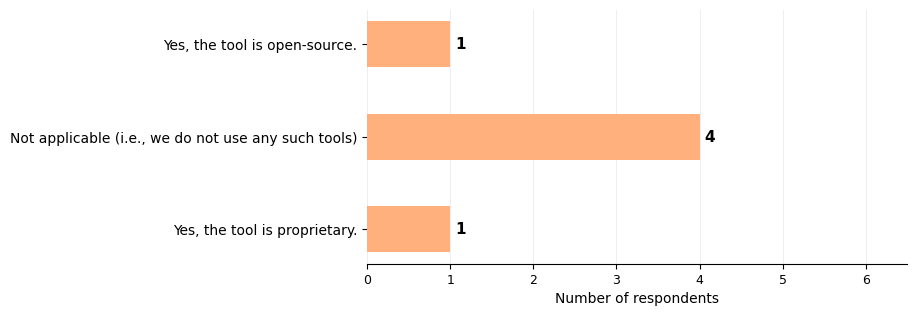

Saved: fig_27_poc_tools.png


In [13]:
q19 = simple_counts("Q19")
print(f"Q19 — Bug Triage Method (n={sum(q19.values())}/{N}):")
for k,v in q19.most_common(): print(f"  {k}: {v}")
hbar(q19, "fig_26_triage_method.png", max_x=5)

q20 = simple_counts("Q20")
print(f"\nQ20 — Automated PoC Tools (n={sum(q20.values())}/{N}):")
for k,v in q20.most_common(): print(f"  {k}: {v}")
hbar(q20, "fig_27_poc_tools.png", max_x=5)


Q19 — Raw triage responses (n=6/13):
  A small group of developers is responsible for bug triage (triagers). This is done manually.: 4
  A small group of developers is responsible for bug triage (triagers). This is in part technology-assisted (e.g., using AI).: 1
  All developers are involved in bug triage. This is partly technology-assisted (e.g., using AI).: 1

Collapsed: {'Manual': 4, 'AI-assisted': 2}


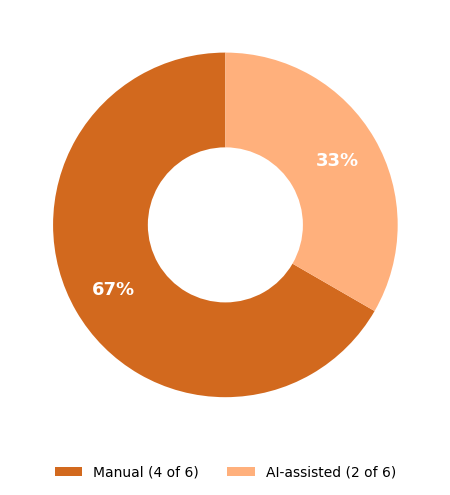

Saved: fig_26_triage_method.png


In [14]:
# Q19 — Bug Triage Method (collapsed into Manual vs AI-assisted)
q19_raw = simple_counts("Q19")
print(f"Q19 — Raw triage responses (n={sum(q19_raw.values())}/{N}):")
for k,v in q19_raw.most_common(): print(f"  {k}: {v}")

# Collapse into Manual vs AI-assisted
manual_keys = [
    "A small group of developers is responsible for bug triage (triagers). This is done manually.",
    "All developers are involved in bug triage. This is done manually."
]
ai_keys = [
    "A small group of developers is responsible for bug triage (triagers). This is in part technology-assisted (e.g., using AI).",
    "All developers are involved in bug triage. This is partly technology-assisted (e.g., using AI).",
    "We possess a fully automated system (e.g., using AI) for bug triage."
]

manual_count = sum(q19_raw.get(k, 0) for k in manual_keys)
ai_count     = sum(q19_raw.get(k, 0) for k in ai_keys)
total        = manual_count + ai_count

collapsed = {"Manual": manual_count, "AI-assisted": ai_count}
print(f"\nCollapsed: {collapsed}")

# Donut chart
fig, ax = plt.subplots(figsize=(5.5, 5))
colours = ["#D2691E", "#ffb07c"]
wedges, _, autotexts = ax.pie(
    [manual_count, ai_count],
    colors=colours, autopct="%1.0f%%",
    startangle=90, wedgeprops=dict(width=0.55),
    pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(13); at.set_fontweight("bold"); at.set_color("white")

ax.legend(wedges,
          [f"Manual ({manual_count} of {total})", f"AI-assisted ({ai_count} of {total})"],
          loc="lower center", bbox_to_anchor=(0.5, -0.12),
          fontsize=10, frameon=False, ncol=2)
fig.tight_layout()
save(fig, "fig_26_triage_method.png")

## Q22 — Bug Management Lifecycle

Q22 — Bug Lifecycle (n=6/13):
  Informal and mostly ad hoc: 2
  Defined process but inconsistently followed: 1
  Well-defined and consistently followed: 1
  Highly structured and tool-supported: 2


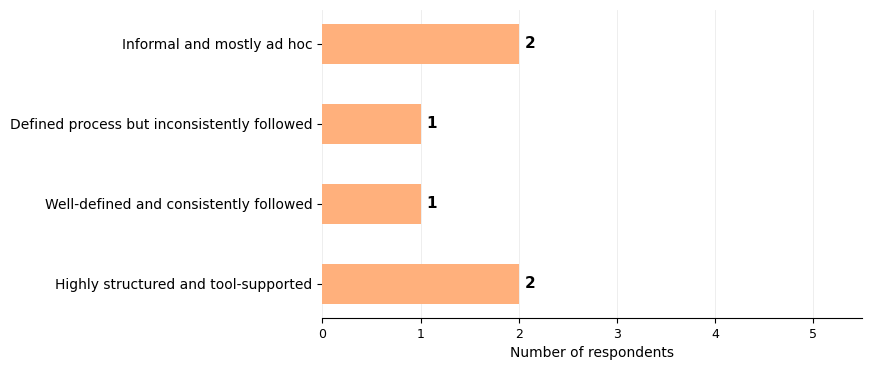

Saved: fig_28_bug_lifecycle.png


In [15]:
lc_order = ["Informal and mostly ad hoc","Defined process but inconsistently followed",
            "Well-defined and consistently followed","Highly structured and tool-supported","Not applicable"]
lc_raw  = simple_counts("Q22")
lc_cnt  = OrderedDict((k, lc_raw[k]) for k in lc_order if k in lc_raw)
for k,v in lc_raw.items():
    if k not in lc_cnt: lc_cnt[k] = v
print(f"Q22 — Bug Lifecycle (n={sum(lc_cnt.values())}/{N}):")
for k,v in lc_cnt.items(): print(f"  {k}: {v}")
hbar(lc_cnt, "fig_28_bug_lifecycle.png", max_x=4)


## Q23 — Severity Classification Approach

In [16]:
q23 = simple_counts("Q23")
print(f"Q23 — Severity Classification (n={sum(q23.values())}/{N}):")
for k,v in q23.most_common(): print(f"  {k}: {v}")
hbar(q23, "fig_29_severity_classification.png", max_x=4)


Q23 — Severity Classification (n=0/13):
Skipped fig_29_severity_classification.png — no data
